In [23]:
#import packages
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from pathlib import Path

In [24]:
#Import the data 

"""
#Method 1 : use simple relative path

# Read the CSV with the relative path

df=pd.read_csv('refinitiv_data/nvda_options_20260204_210456.csv')

 # it exists a more robust method.
"""

#Method 2 : use Pathlib

#Get the directory where the notebook is located

notebook_dir = Path.cwd()


# Build the path to the CSV file
csv_file = notebook_dir / 'refinitiv_data' / 'nvda_options_20260204_210456.csv'

df=pd.read_csv(csv_file)



df.head()

,Instrument,Implied Volatility,Strike Price,Expiry Date,BID,ASK,CF_LAST,PUTCALLIND
0,NVDAB202619000.U,40.4573,190.0,2026-02-20,1.55,1.58,1.55,CALL
1,NVDAB202618000.U,43.4314,180.0,2026-02-20,4.55,4.60,4.55,CALL
2,NVDAN202618000.U,43.2729,180.0,2026-02-20,8.60,8.70,8.49,PUT
3,NVDAB202618500.U,41.8484,185.0,2026-02-20,2.73,2.76,2.75,CALL
4,NVDAC202620000.U,45.9441,200.0,2026-03-20,3.75,3.85,3.80,CALL


In [25]:
#Renaming the columns in a more convenient way
df= df.copy()


df.columns = ['instrument', 'iv', 'strike', 'expiry', 'bid', 'ask', 'last', 'type_option']

# Ensure expiry is datetime
df['expiry'] = pd.to_datetime(df['expiry'])


# Clean data (remove trailing spaces)

df['type_option'] = df['type_option'].str.strip()


In [26]:
df.head()

,instrument,iv,strike,expiry,bid,ask,last,type_option
0,NVDAB202619000.U,40.4573,190.0,2026-02-20,1.55,1.58,1.55,CALL
1,NVDAB202618000.U,43.4314,180.0,2026-02-20,4.55,4.60,4.55,CALL
2,NVDAN202618000.U,43.2729,180.0,2026-02-20,8.60,8.70,8.49,PUT
3,NVDAB202618500.U,41.8484,185.0,2026-02-20,2.73,2.76,2.75,CALL
4,NVDAC202620000.U,45.9441,200.0,2026-03-20,3.75,3.85,3.80,CALL


In [27]:
df.describe()

#the mean is very high, looking at the data there is some huge values (>700 !)
#let's filter those values

,iv,strike,expiry,bid,ask,last
count,1000.000000,1000.00000,1000,991.000000,991.000000,991.000000
mean,80.455764,147.55300,2026-10-07 21:14:24,40.140373,40.754753,40.655237
min,38.617900,0.50000,2026-01-30 00:00:00,0.000000,0.010000,0.010000
25%,46.179675,95.00000,2026-03-20 00:00:00,5.550000,5.625000,5.490000
50%,48.967100,165.00000,2026-06-18 00:00:00,24.550000,24.650000,24.710000
75%,80.755175,195.00000,2027-01-15 00:00:00,51.425000,51.975000,51.025000
max,939.225100,380.00000,2028-12-15 00:00:00,203.550000,205.350000,199.650000
std,82.023650,80.63104,NaN,47.389229,48.455843,48.629794


In [28]:
# Filter out Refinitiv garbage data (unrealistic strikes)
# Real NVDA options have strikes roughly $50 - $500
df = df[
    (df['strike'] >= 50) &     # Remove fake low strikes ($0.50, $1.50, etc.)
    (df['strike'] <= 500)      # Remove unrealistic high strikes
].copy()

print(f"After filtering: {len(df)} options")
print(f"Strike range: ${df['strike'].min():.0f} - ${df['strike'].max():.0f}")

After filtering: 822 options
Strike range: $50 - $380


In [29]:
#Implementing bid ask spread
#Quantify liquidity on the df

# CORRECT formula
df["bid_ask_spread"] = (df["ask"] - df["bid"]) / (0.5 * (df["bid"] + df["ask"]))


df.head()

,instrument,iv,strike,expiry,bid,ask,last,type_option,bid_ask_spread
0,NVDAB202619000.U,40.4573,190.0,2026-02-20,1.55,1.58,1.55,CALL,0.019169
1,NVDAB202618000.U,43.4314,180.0,2026-02-20,4.55,4.60,4.55,CALL,0.010929
2,NVDAN202618000.U,43.2729,180.0,2026-02-20,8.60,8.70,8.49,PUT,0.011561
3,NVDAB202618500.U,41.8484,185.0,2026-02-20,2.73,2.76,2.75,CALL,0.010929
4,NVDAC202620000.U,45.9441,200.0,2026-03-20,3.75,3.85,3.80,CALL,0.026316


- Added here column time to maturity in the df, normalized using 365.25 (include leap years)
- We will need it to get the forward price further in the notebook

In [30]:
# Data capture timestamp
capture_date = pd.to_datetime('2026-02-04')

# Add time to expiry (in years)
df['time_to_maturity'] = (df['expiry'] - capture_date).dt.days / 365.25  # Use 365.25 for leap years

# Check it
print(df[['expiry', 'time_to_maturity']].drop_duplicates().sort_values('time_to_maturity'))

        expiry  time_to_maturity
136 2026-01-30         -0.013689
34  2026-02-06          0.005476
0   2026-02-20          0.043806
4   2026-03-20          0.120465
881 2026-04-17          0.197125
58  2026-05-15          0.273785
106 2026-06-18          0.366872
137 2026-07-17          0.446270
131 2026-08-21          0.542094
143 2026-09-18          0.618754
165 2026-12-18          0.867899
99  2027-01-15          0.944559
173 2027-06-17          1.363450
190 2027-12-17          1.864476
249 2028-01-21          1.960301
274 2028-12-15          2.861054


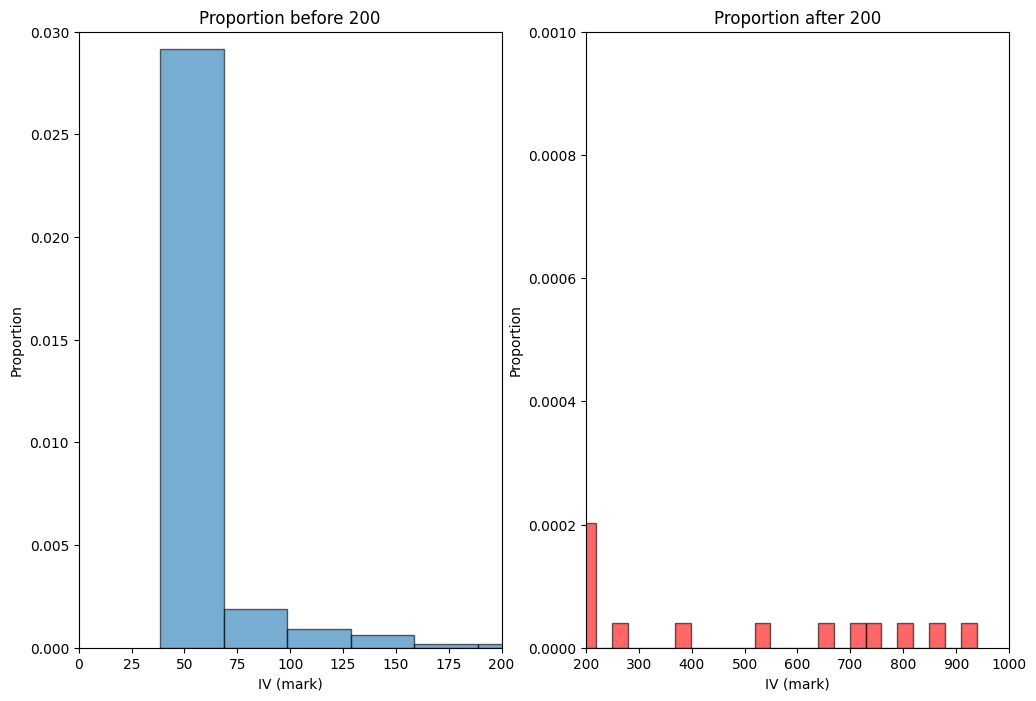

In [31]:
fig, axes = plt.subplots(1,2,figsize=(12,8))
axes[0].hist(df["iv"], bins=30, density=True, alpha=0.6, edgecolor='black')
axes[0].set_xlim(0,200)
axes[0].set_ylim(0, 0.03)
axes[0].set_xlabel("IV (mark)")
axes[0].set_ylabel("Proportion")
axes[0].set_title("Proportion before 200")

axes[1].hist(df["iv"], bins=30, density=True, color = "red", alpha=0.6, edgecolor='black')
axes[1].set_xlim(200,1000)
axes[1].set_ylim(0, 0.001)
axes[1].set_xlabel("IV (mark)")
axes[1].set_ylabel("Proportion")
axes[1].set_title("Proportion after 200")

plt.show()

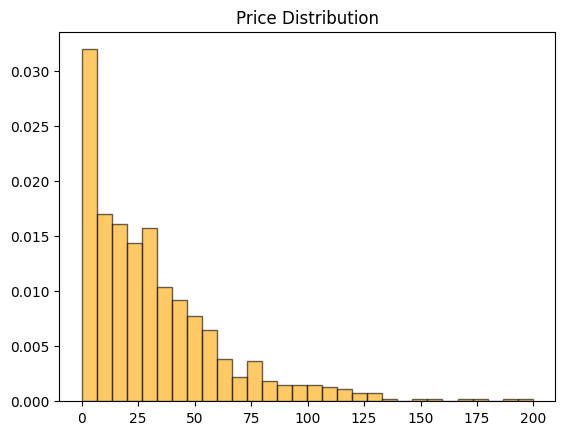

In [32]:
plt.hist(df["last"], bins=30, color="orange", density=True, alpha=0.6, edgecolor='black')
plt.title("Price Distribution")
plt.show()

In [33]:
df_sorted=df[df["iv"]<=350].copy()

df_sorted


,instrument,iv,strike,expiry,bid,ask,last,type_option,bid_ask_spread,time_to_maturity
0,NVDAB202619000.U,40.4573,190.0,2026-02-20,1.55,1.58,1.55,CALL,0.019169,0.043806
1,NVDAB202618000.U,43.4314,180.0,2026-02-20,4.55,4.60,4.55,CALL,0.010929,0.043806
2,NVDAN202618000.U,43.2729,180.0,2026-02-20,8.60,8.70,8.49,PUT,0.011561,0.043806
3,NVDAB202618500.U,41.8484,185.0,2026-02-20,2.73,2.76,2.75,CALL,0.010929,0.043806
4,NVDAC202620000.U,45.9441,200.0,2026-03-20,3.75,3.85,3.80,CALL,0.026316,0.120465
...,...,...,...,...,...,...,...,...,...,...
993,NVDAL172712000.U,53.0541,120.0,2027-12-17,78.55,79.50,78.10,CALL,0.012022,1.864476
994,NVDAX172707000.U,55.0331,70.0,2027-12-17,3.35,3.50,3.50,PUT,0.043796,1.864476
995,NVDAE152608000.U,75.7454,80.0,2026-05-15,96.30,97.35,101.48,CALL,0.010844,0.273785
997,NVDAF182638000.U,49.1091,380.0,2026-06-18,0.16,0.17,0.16,CALL,0.060606,0.366872


In [34]:
df_sorted.describe()

,iv,strike,expiry,bid,ask,last,bid_ask_spread,time_to_maturity
count,814.000000,814.000000,814,813.000000,813.000000,813.000000,813.000000,814.000000
mean,55.695107,176.665848,2026-10-16 21:29:37.886978,31.830172,32.108278,31.777171,0.071179,0.697866
min,38.617900,50.000000,2026-01-30 00:00:00,0.000000,0.010000,0.010000,0.001166,-0.013689
25%,45.793550,145.000000,2026-03-20 00:00:00,8.450000,8.600000,8.500000,0.006169,0.120465
50%,47.762000,177.000000,2026-06-18 00:00:00,24.600000,24.750000,24.770000,0.008949,0.366872
75%,51.690375,200.000000,2027-01-15 00:00:00,45.000000,45.250000,45.450000,0.014225,0.944559
max,250.323200,380.000000,2028-12-15 00:00:00,203.550000,205.350000,199.650000,2.000000,2.861054
std,24.434373,57.312957,NaN,31.192411,31.486269,30.881399,0.306641,0.695937


In [35]:
threshold = 100
df[df["iv"] > threshold ]
#ok we see that they are a lot of options with no bid and no ask => totally illiquid. 

,instrument,iv,strike,expiry,bid,ask,last,type_option,bid_ask_spread,time_to_maturity
136,NVDAA302609000.U,851.3641,90.0,2026-01-30,NaN,NaN,NaN,CALL,NaN,-0.013689
144,NVDAA302611000.U,650.8231,110.0,2026-01-30,NaN,NaN,NaN,CALL,NaN,-0.013689
145,NVDAM302607500.U,707.8410,75.0,2026-01-30,NaN,NaN,NaN,PUT,NaN,-0.013689
154,NVDAM302609500.U,538.6125,95.0,2026-01-30,NaN,NaN,NaN,PUT,NaN,-0.013689
158,NVDAA302609500.U,814.6601,95.0,2026-01-30,NaN,NaN,NaN,CALL,NaN,-0.013689
162,NVDAA302607000.U,939.2251,70.0,2026-01-30,NaN,NaN,NaN,CALL,NaN,-0.013689
164,NVDAM302607000.U,757.4155,70.0,2026-01-30,NaN,NaN,NaN,PUT,NaN,-0.013689
176,NVDAB202611000.U,101.0596,110.0,2026-02-20,65.80,65.95,65.82,CALL,0.002277,0.043806
191,NVDAN202610000.U,104.4949,100.0,2026-02-20,0.04,0.05,0.05,PUT,0.222222,0.043806
208,NVDAB202610500.U,105.3982,105.0,2026-02-20,70.80,70.90,70.83,CALL,0.001411,0.043806


In [36]:
df_sorted.dropna(inplace=True)
df_sorted.describe()

,iv,strike,expiry,bid,ask,last,bid_ask_spread,time_to_maturity
count,813.000000,813.000000,813,813.000000,813.000000,813.000000,813.000000,813.000000
mean,55.455712,176.557196,2026-10-17 05:09:57.785977,31.830172,32.108278,31.777171,0.071179,0.698741
min,38.617900,50.000000,2026-02-06 00:00:00,0.000000,0.010000,0.010000,0.001166,0.005476
25%,45.792500,145.000000,2026-03-20 00:00:00,8.450000,8.600000,8.500000,0.006169,0.120465
50%,47.758000,177.000000,2026-06-18 00:00:00,24.600000,24.750000,24.770000,0.008949,0.366872
75%,51.680400,200.000000,2027-01-15 00:00:00,45.000000,45.250000,45.450000,0.014225,0.944559
max,209.471300,380.000000,2028-12-15 00:00:00,203.550000,205.350000,199.650000,2.000000,2.861054
std,23.474798,57.264291,NaN,31.192411,31.486269,30.881399,0.306641,0.695917


In [37]:
#df_sorted was maybe too restrictive removing information of high vol options
#we will keep only filtration about liquidity



liq_threshold = 2 #after analysis, volontarily chosen high threshold to see OTM PUTS

#retaining only options which bid_ask_spread <= threshold %

df_liq = df[df["bid_ask_spread"] <= liq_threshold].copy()

#Clean data
df_liq['type_option'] = df_liq['type_option'].str.strip()
df_liq = df_liq.dropna()
df_liq['expiry'] = pd.to_datetime(df_liq['expiry'])

#Separate calls and puts
df_liq_calls = df_liq[df_liq['type_option'] == 'CALL'].copy()
df_liq_puts = df_liq[df_liq['type_option'] == 'PUT'].copy()

df_liq= df[df["bid_ask_spread"] <= liq_threshold].copy()
df_liq.describe()

,iv,strike,expiry,bid,ask,last,bid_ask_spread,time_to_maturity
count,813.000000,813.000000,813,813.000000,813.000000,813.000000,813.000000,813.000000
mean,55.455712,176.557196,2026-10-17 05:09:57.785977,31.830172,32.108278,31.777171,0.071179,0.698741
min,38.617900,50.000000,2026-02-06 00:00:00,0.000000,0.010000,0.010000,0.001166,0.005476
25%,45.792500,145.000000,2026-03-20 00:00:00,8.450000,8.600000,8.500000,0.006169,0.120465
50%,47.758000,177.000000,2026-06-18 00:00:00,24.600000,24.750000,24.770000,0.008949,0.366872
75%,51.680400,200.000000,2027-01-15 00:00:00,45.000000,45.250000,45.450000,0.014225,0.944559
max,209.471300,380.000000,2028-12-15 00:00:00,203.550000,205.350000,199.650000,2.000000,2.861054
std,23.474798,57.264291,NaN,31.192411,31.486269,30.881399,0.306641,0.695917


- No real effect on the data even with 0.3 
- Our 757 options already sorted with normal iv and removing pure illiquid options have a threshold <= 0.3

In [38]:
#All expiries
print(df['expiry'].unique())

<DatetimeArray>
['2026-02-20 00:00:00', '2026-03-20 00:00:00', '2026-02-06 00:00:00',
 '2026-05-15 00:00:00', '2027-01-15 00:00:00', '2026-06-18 00:00:00',
 '2026-08-21 00:00:00', '2026-01-30 00:00:00', '2026-07-17 00:00:00',
 '2026-09-18 00:00:00', '2026-12-18 00:00:00', '2027-06-17 00:00:00',
 '2027-12-17 00:00:00', '2028-01-21 00:00:00', '2028-12-15 00:00:00',
 '2026-04-17 00:00:00']
Length: 16, dtype: datetime64[us]


Most represented maturity is 2026-06-18 00:00:00 with 151 options


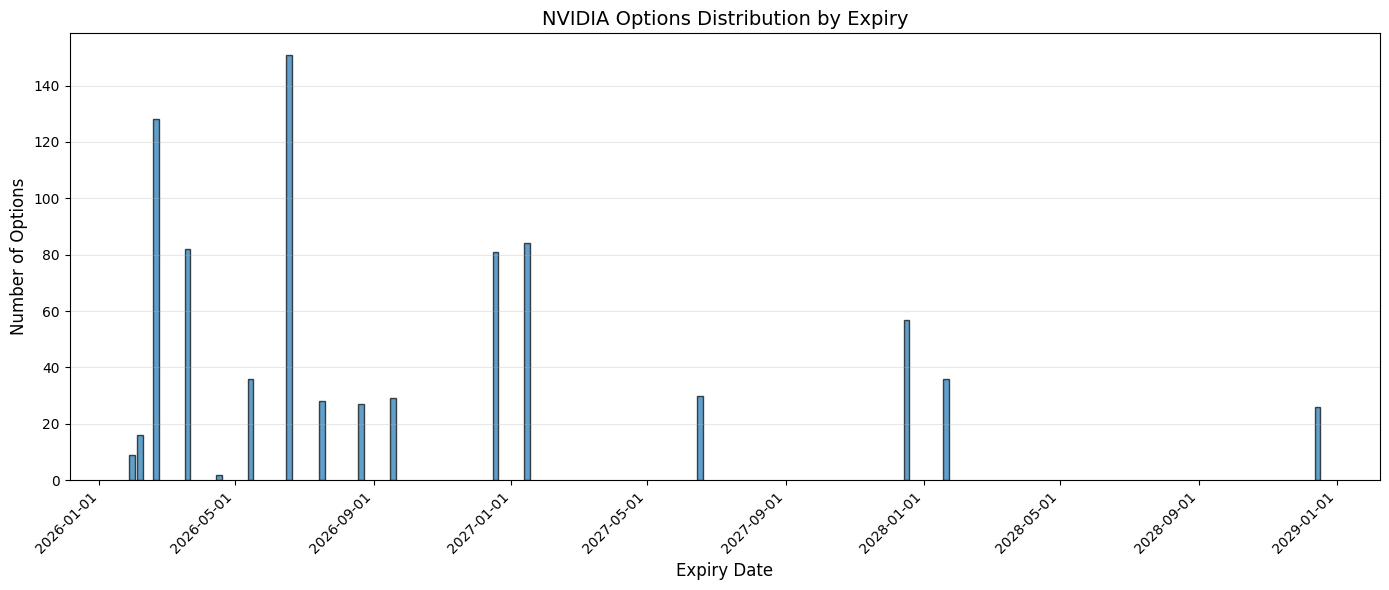

In [39]:
import matplotlib.dates as mdates


# Find most common expiry
most_common_expiry = df['expiry'].value_counts().idxmax()
count = df['expiry'].value_counts().max()
print(f"Most represented maturity is {most_common_expiry} with {count} options")

# Group by expiry and count
df_grouped = df.groupby('expiry').size().reset_index(name='count')
df_grouped = df_grouped.sort_values('expiry')  # Sort by date

#Create bar plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(df_grouped['expiry'], df_grouped['count'], width=5, edgecolor='black', alpha=0.7)

#Format x-axis dates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
# Labels and formatting
ax.set_xlabel('Expiry Date', fontsize=12)
ax.set_ylabel('Number of Options', fontsize=12)
ax.set_title('NVIDIA Options Distribution by Expiry', fontsize=14)
ax.grid(axis='y', alpha=0.3)

# 6. Rotate labels
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Vol Surface

## 2D (Skew)

### First : connect the dot naïvely

- Case with the filtered data
- case with raw data

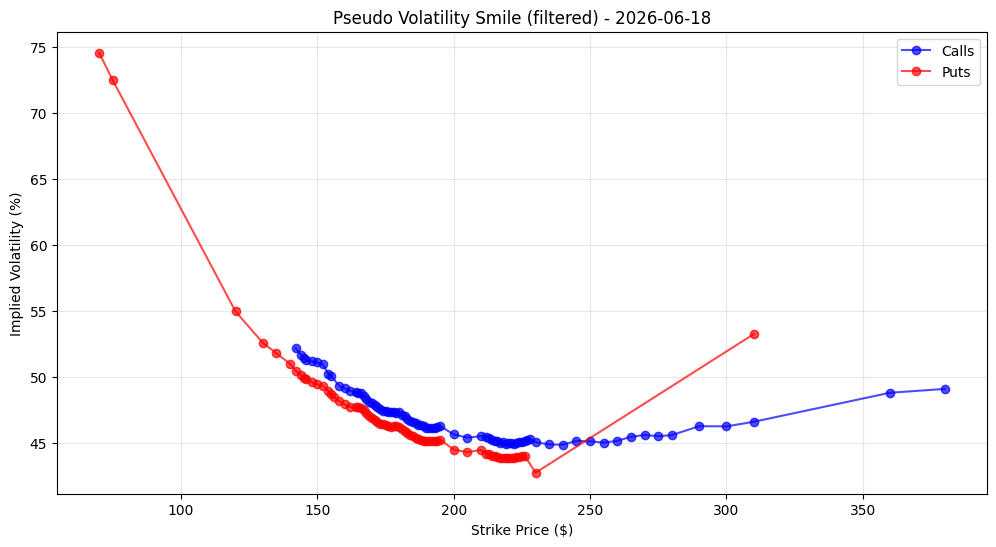

In [40]:
# Select expiry date
expiry_date = pd.to_datetime('2026-06-18')

# Filter by expiry and sort
df_calls = df_liq_calls[df_liq_calls['expiry'] == expiry_date].sort_values('strike').copy()
df_puts = df_liq_puts[df_liq_puts['expiry'] == expiry_date].sort_values('strike').copy()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df_calls['strike'], df_calls['iv'], 'b-o', label='Calls', alpha=0.7)
plt.plot(df_puts['strike'], df_puts['iv'], 'r-o', label='Puts', alpha=0.7)
plt.xlabel('Strike Price ($)')
plt.ylabel('Implied Volatility (%)')
plt.title(f'Pseudo Volatility Smile (filtered) - {expiry_date.date()}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Comparing it with raw data

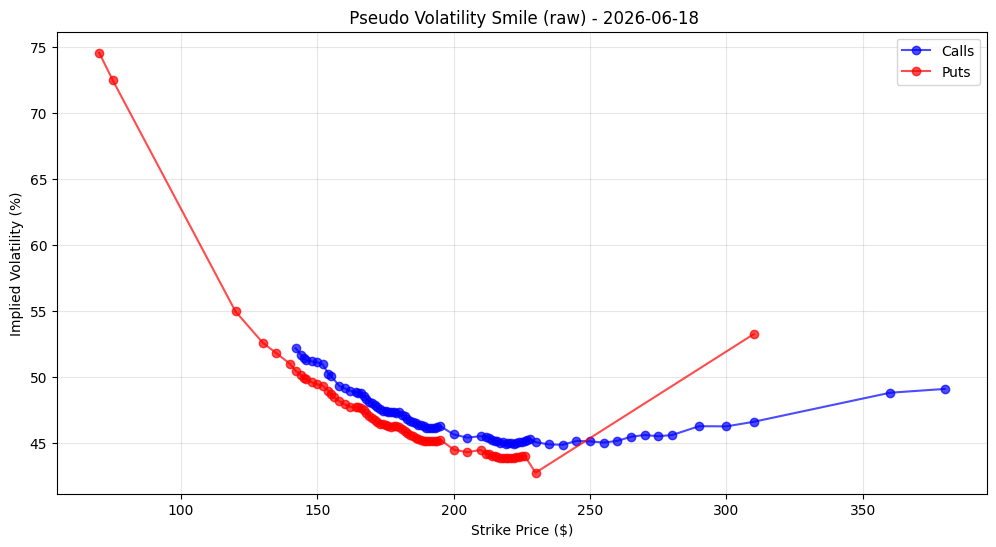

In [41]:
expiry_date = pd.to_datetime('2026-06-18')

# Filter by expiry
df_raw = df[df["expiry"] == expiry_date].copy()

# Separate calls and puts
df_calls = df_raw[df_raw["type_option"] == 'CALL'].sort_values('strike').copy()
df_puts = df_raw[df_raw["type_option"] == 'PUT'].sort_values('strike').copy()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df_calls['strike'], df_calls['iv'], 'b-o', label='Calls', alpha=0.7)
plt.plot(df_puts['strike'], df_puts['iv'], 'r-o', label='Puts', alpha=0.7)
plt.xlabel('Strike Price ($)')
plt.ylabel('Implied Volatility (%)')
plt.title(f' Pseudo Volatility Smile (raw) - {expiry_date.date()}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## With Moneyness

### NVDA stock price
S = 174.19

### Objective : get the forward price

- Formula : $F = S × e^{(r \times T)}$

### Risk-free rate
- See fonction below



In [42]:
# Constants
S = 174.19  # NVDA spot price at import time
capture_date = pd.to_datetime('2026-02-04')

# Calculate time to expiry (in years) - THIS IS CRITICAL
df_liq['T'] = (df_liq['expiry'] - capture_date).dt.days / 365.25

# Risk-free rate function
def get_risk_free_rate(T):
    """
    Match Treasury rate to option maturity
    Based on Feb 6, 2026 Treasury yields 
    """
    if T < 0.25:      # < 3 months
        return 0.03598   # 3.598% (US3MT)
    elif T < 0.5:     # 3-6 months  
        return 0.03513   # 3.513% (US6MT)
    elif T < 1.0:     # 6-12 months
        return 0.03328   # 3.328% (US1YT)
    else:             # > 1 year
        return 0.0325    # 3.25% (US2YT estimated)

# Apply to each option (use T, not expiry!)
df_liq['r'] = df_liq['T'].apply(get_risk_free_rate)

# Calculate forward prices (use T, not expiry!)
df_liq['forward'] = S * np.exp(df_liq['r'] * df_liq['T'])

# Check results
print(df_liq[['expiry', 'T', 'r', 'forward']].drop_duplicates().sort_values('T'))

        expiry         T        r     forward
34  2026-02-06  0.005476  0.03598  174.224322
0   2026-02-20  0.043806  0.03598  174.464762
4   2026-03-20  0.120465  0.03598  174.946638
881 2026-04-17  0.197125  0.03598  175.429846
58  2026-05-15  0.273785  0.03513  175.873454
106 2026-06-18  0.366872  0.03513  176.449527
137 2026-07-17  0.446270  0.03513  176.942374
131 2026-08-21  0.542094  0.03328  177.361063
143 2026-09-18  0.618754  0.03328  177.814132
165 2026-12-18  0.867899  0.03328  179.294611
99  2027-01-15  0.944559  0.03328  179.752619
173 2027-06-17  1.363450  0.03250  182.082298
190 2027-12-17  1.864476  0.03250  185.071482
249 2028-01-21  1.960301  0.03250  185.648750
274 2028-12-15  2.861054  0.03250  191.163850


Expiry: 2026-06-18
Time to expiry: 0.367 years
Risk-free rate: 0.0351 (3.51%)
Forward price: $176.45


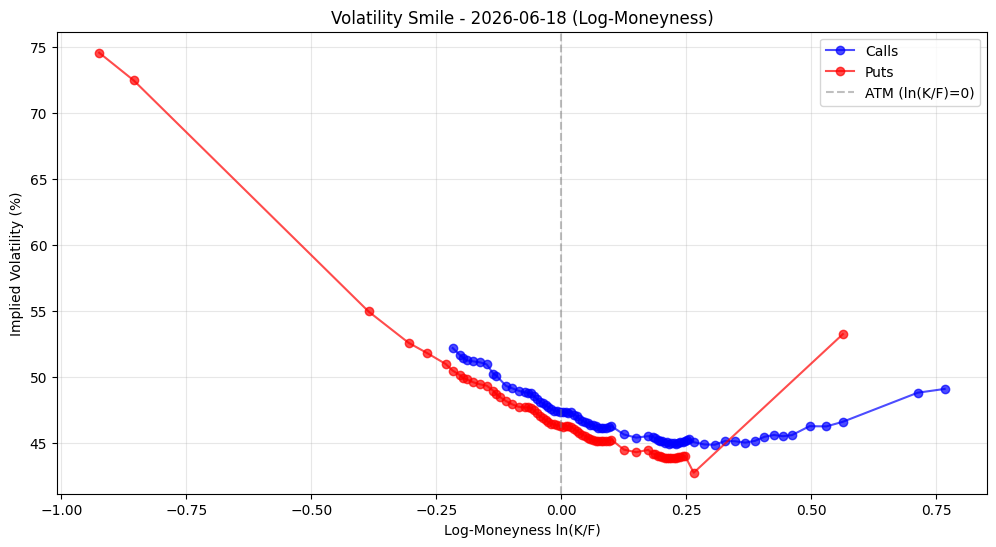

In [43]:
# Select expiry date
expiry_date = pd.to_datetime('2026-06-18')

# Filter by expiry
df_calls = df_liq_calls[df_liq_calls['expiry'] == expiry_date].sort_values('strike').copy()
df_puts = df_liq_puts[df_liq_puts['expiry'] == expiry_date].sort_values('strike').copy()

# Calculate forward price for this expiry
S = 174.19
capture_date = pd.to_datetime('2026-02-04')
T = (expiry_date - capture_date).days / 365.25

# Get risk-free rate for this maturity
if T < 0.25:
    r = 0.03598
elif T < 0.5:
    r = 0.03513
elif T < 1.0:
    r = 0.03328
else:
    r = 0.0325

forward = S * np.exp(r * T)

print(f"Expiry: {expiry_date.date()}")
print(f"Time to expiry: {T:.3f} years")
print(f"Risk-free rate: {r:.4f} ({r*100:.2f}%)")
print(f"Forward price: ${forward:.2f}")

# Calculate log-moneyness
df_calls['log_moneyness'] = np.log(df_calls['strike'] / forward)
df_puts['log_moneyness'] = np.log(df_puts['strike'] / forward)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df_calls['log_moneyness'], df_calls['iv'], 'b-o', label='Calls', alpha=0.7)
plt.plot(df_puts['log_moneyness'], df_puts['iv'], 'r-o', label='Puts', alpha=0.7)
plt.axvline(x=0, color='gray', linestyle='--', label='ATM (ln(K/F)=0)', alpha=0.5)
plt.xlabel('Log-Moneyness ln(K/F)')
plt.ylabel('Implied Volatility (%)')
plt.title(f'Volatility Smile - {expiry_date.date()} (Log-Moneyness)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Now, need to interpolate and compute no arbitrage conditions